# IMPORT

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE

# LOAD DATA

In [3]:
X = np.load("saved/X.npy", allow_pickle=True)
Y = np.load("saved/Y_encoded.npy", allow_pickle=True)
groups = np.load("saved/groups.npy", allow_pickle=True)

print(f"X.shape: {X.shape}, Y.shape: {Y.shape}, groups.shape: {groups.shape}")

X.shape: (3953, 86), Y.shape: (3953, 90), groups.shape: (3953,)


# HISTOGRAM

Label counts: [ 73  28  47 158  29   5  36 189 108 343 781  40  28   4  49 542  28   2
 627 167  55 350 818  24  48  46  24  30  46  14  66  34   6  36  96  34
  12  66  72  10  72  24  24  24  86  24  10  24  44  48  48  48 168  26
 626 420  18 666 298  18   4   4  18  28   4 130  70  76   6   6   4  20
   6  74  10  22  26   2  10  24   8   2   2   2   4   4  52  86   2 126], count: 90, min: 2, max: 818, mean: 96.87777777777778


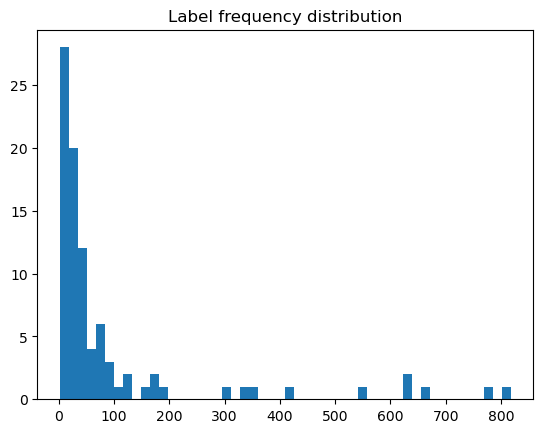

In [4]:
label_counts = Y.sum(axis=0)

print(f"Label counts: {label_counts}, count: {label_counts.shape[0]}, min: {label_counts.min()}, max: {label_counts.max()}, mean: {label_counts.mean()}")

plt.hist(label_counts, bins=50)
plt.title("Label frequency distribution")
plt.show()

# ACTIVE LABELS PER SAMPLE

labels_per_sample: [1 1 1 ... 5 5 4], count: 3953, min: 1, max: 10, mean: 2.2056665823425248


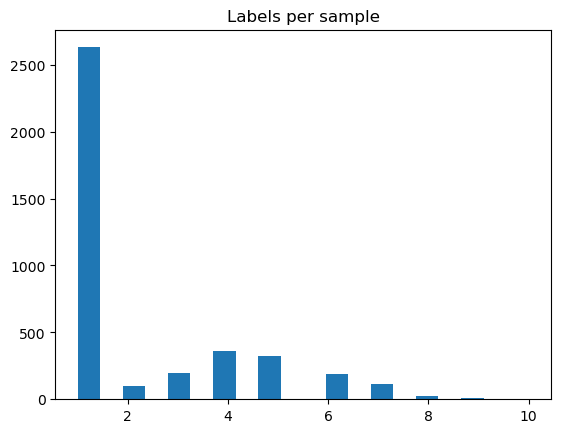

In [5]:
labels_per_sample = Y.sum(axis=1)
print(f"labels_per_sample: {labels_per_sample}, count: {labels_per_sample.shape[0]}, min: {labels_per_sample.min()}, max: {labels_per_sample.max()}, mean: {labels_per_sample.mean()}")

plt.hist(labels_per_sample, bins=20)
plt.title("Labels per sample")
plt.show()

# FEATURE DISTRIBUTION

Mean: 174.34152075307486
Std: 936.5916724906124
Min: -1129.8277587890625
Max: 14832.567891373801


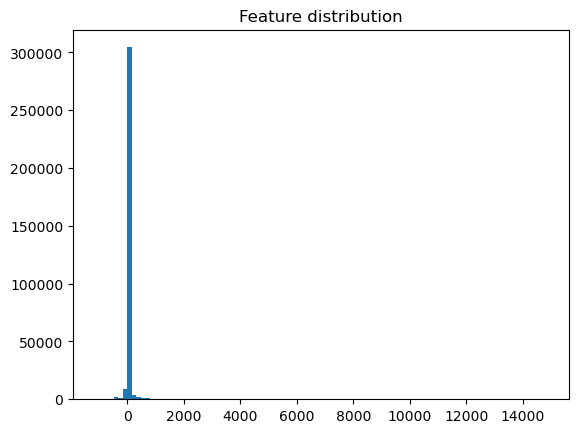

In [6]:
print("Mean:", np.mean(X))
print("Std:", np.std(X))
print("Min:", np.min(X))
print("Max:", np.max(X))

plt.hist(X.flatten(), bins=100)
plt.title("Feature distribution")
plt.show()

# PCA VARIANCE

Explained variance ratio: [8.43510518e-01 9.92178705e-02 4.13354691e-02 7.86661797e-03
 4.46797783e-03 1.64179846e-03 1.40108940e-03 1.70726454e-04
 8.77666607e-05 5.62688319e-05 4.74242148e-05 4.01422601e-05
 3.14375764e-05 2.77927590e-05 1.88169171e-05 1.75479161e-05
 1.42833783e-05 1.18186242e-05 9.12096934e-06 8.22295810e-06
 5.33017084e-06 4.41243879e-06 2.48344932e-06 1.42139062e-06
 7.64641291e-07 6.83953794e-07 5.46938690e-07 3.78398840e-07
 3.39919791e-07 2.38371301e-07 1.63927533e-07 1.32541415e-07
 1.02025633e-07 6.92325203e-08 5.04224880e-08 4.84421634e-08
 2.74268165e-08 1.84055784e-08 1.50998737e-08 9.00890459e-09
 8.59903501e-09 5.96522274e-09 5.47238400e-09 4.96652396e-09
 4.08028897e-09 3.06483179e-09 2.74853095e-09 2.42937102e-09
 2.07535719e-09 1.74997479e-09 1.50511744e-09 1.46621282e-09
 1.01748566e-09 9.69070110e-10 8.50874199e-10 7.47246175e-10
 6.18035819e-10 5.39748393e-10 4.41479979e-10 4.15061578e-10
 3.86966756e-10 3.39988335e-10 2.87259541e-10 2.85728978e-1

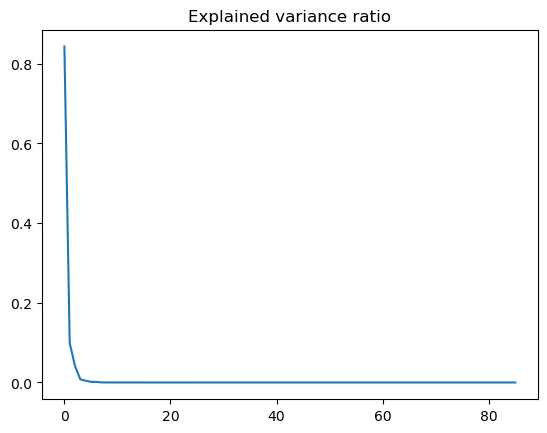

In [7]:
pca = PCA()
pca.fit(X)


print(f"Explained variance ratio: {pca.explained_variance_ratio_}, sum: {pca.explained_variance_ratio_.sum()}")
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained variance ratio")
plt.show()

# PCA WITH SAMPLING AND LABEL COLORING

X_pca[:,0]: [ -966.686949    -487.57289531 -1968.84689    ... -1655.30134987
 -1525.23227852 -4596.40828103], X_pca[:,1]: [-823.71925538 -174.64966743 -431.41950429 ... -923.98833661 -954.63265591
 1228.1569663 ]


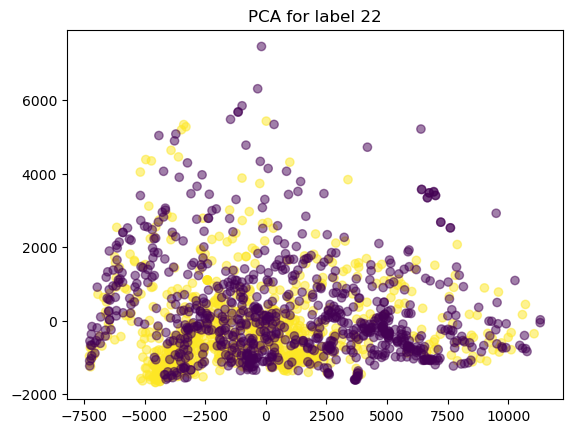

In [8]:
# pick one label with enough positives
label_id = np.argmax(label_counts)

mask = Y[:, label_id] == 1

# balance visualization
idx_pos = np.where(mask)[0]
idx_neg = np.where(~mask)[0][:len(idx_pos)]

idx = np.concatenate([idx_pos, idx_neg])

X_pca = PCA(n_components=2).fit_transform(X[idx])

print(f"X_pca[:,0]: {X_pca[:,0]}, X_pca[:,1]: {X_pca[:,1]}")

plt.scatter(X_pca[:,0], X_pca[:,1], c=Y[idx, label_id], alpha=0.5)
plt.title(f"PCA for label {label_id}")
plt.show()

# T-SNE

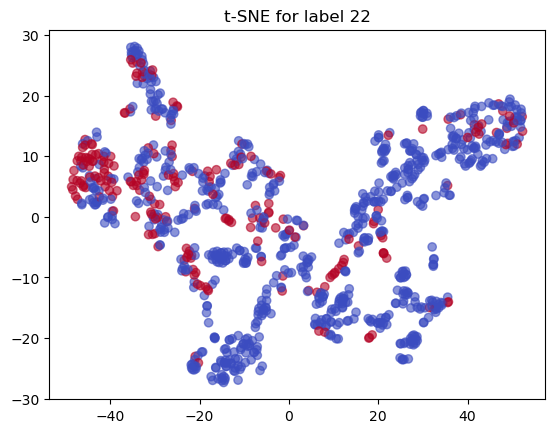

In [9]:
idx = np.random.choice(len(X), size=1000, replace=False)

X_sample = X[idx]
Y_sample = Y[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# choose one label to visualize
label_id = np.argmax(Y.sum(axis=0))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=Y_sample[:, label_id],
    cmap="coolwarm",
    alpha=0.6
)
plt.title(f"t-SNE for label {label_id}")
plt.show()

# CORRELATION

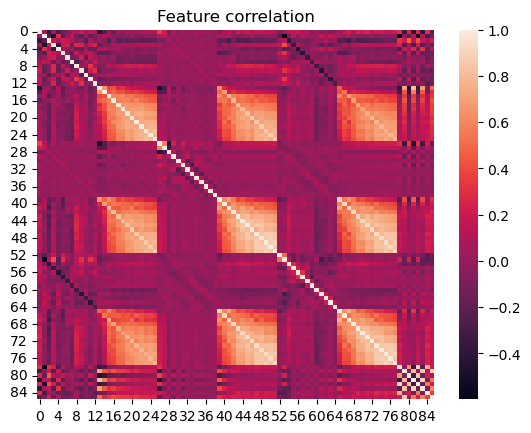

In [ ]:
corr = np.corrcoef(X.T)
sns.heatmap(corr)
plt.title("Feature correlation")
plt.show()

# TRAIN AND TEST LABEL COUNT

In [11]:
print("Train label counts:", Y.sum(axis=0))
print("Test label counts:", Y.sum(axis=0))

Train label counts: [ 73  28  47 158  29   5  36 189 108 343 781  40  28   4  49 542  28   2
 627 167  55 350 818  24  48  46  24  30  46  14  66  34   6  36  96  34
  12  66  72  10  72  24  24  24  86  24  10  24  44  48  48  48 168  26
 626 420  18 666 298  18   4   4  18  28   4 130  70  76   6   6   4  20
   6  74  10  22  26   2  10  24   8   2   2   2   4   4  52  86   2 126]
Test label counts: [ 73  28  47 158  29   5  36 189 108 343 781  40  28   4  49 542  28   2
 627 167  55 350 818  24  48  46  24  30  46  14  66  34   6  36  96  34
  12  66  72  10  72  24  24  24  86  24  10  24  44  48  48  48 168  26
 626 420  18 666 298  18   4   4  18  28   4 130  70  76   6   6   4  20
   6  74  10  22  26   2  10  24   8   2   2   2   4   4  52  86   2 126]


# TO USE THIS AS A TEST IN A MODEL

In [12]:
baseline = Y.mean(axis=0)  # constant prediction